# Naive Bayes Spam Classifier

In this notebook, we manually implemented the Naive Bayes classifier for classifying if an email is either a legitimate (ham) or spam email. We extend the base Naive Bayes classifier with techniques such as Lambda smoothing, feature selection, customary vocabulary size, and n-grams as described by (Hovold, 2005).

In [1]:
!pip install -qU matplotlib numpy pandas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import email
import pandas as pd
import time
import pickle

%matplotlib inline

## Base Naive Bayes Classifier
A base Naive Bayes classifier *naively* calculates the posterior distribution using the prior distribution even if the conditional likelihood of a word is zero, collapsing the entire class probability to zero. We extend the Naive Bayes classifier using log probabilities for numerical stability. In the case where the probability is zero, we take the limit of the $\log(0)$ from the right side which is $-\infty$.

$$
\lim_{x\rightarrow 0} \log(x) = -\infty
$$

We then follow the Naive Bayes formula,

$$
P(\omega| \textbf{x})=\frac{\prod_{i=1}^dP(x_i|\omega)P(\omega)}{\sum_\omega\prod_{i=1}^dP(x_i\omega)P(\omega)}
$$

where $P(\omega|\textbf{x})$ is the posterior probability of a vector of words $\textbf{x}$ belonging in class $\omega$, the $P(\omega)$ is the prior distribution, and the $P(x_i|\omega)$ is the class conditional likelihood for word $x_i$ defined as

$$
P(x_i|\omega) = \frac{\sum_{D\in D\omega} I(x_i\in D)}{|D_\omega|}
$$

### Preparing the Data

A subset of TREC06 Public Spam Classifier is used in training the model.

In [3]:
DATA_PATH = os.path.join(os.getcwd(), 'trec06p-ai201')

#### Stratified Train-Test Split

We first perform **stratified train-test split** on the given dataset. We will be splitting the dataset into a 70-30 train-test split using `stratify_dataset` function.

In [4]:
def stratify_dataset(data_path, ratio=0.7, file_paths=["train_set", "test_set"], seed=42):
    with open(data_path, 'r') as f:
        lines = f.readlines()
        ham_data = [line for line in lines if line.startswith("ham")]
        spam_data = [line for line in lines if line.startswith("spam")]
    
        print(f"Attempting to generate a dataset with {ratio} ratio.")
        
        # Generate a randomized dataset with equal spam and ham proportions
        np.random.seed(seed)
        n_train_ham = int(len(ham_data) * ratio)
        n_train_spam = int(len(spam_data) * ratio)
        
        np.random.shuffle(ham_data)
        np.random.shuffle(spam_data)
          
        train_set_ham = ham_data[:n_train_ham]
        test_set_ham = ham_data[n_train_ham:]
          
        train_set_spam = spam_data[:n_train_spam]
        test_set_spam = spam_data[n_train_spam:]
    
        train_set = np.random.permutation(train_set_ham + train_set_spam).tolist()
        test_set = np.random.permutation(test_set_ham + test_set_spam).tolist()
        print(f"Generated train set with {len(train_set)} data points.")
        print(f"Generated test set with {len(test_set)} data points.")

        for path, data in zip(file_paths, [train_set, test_set]):
            with open(path, 'w') as f:
                f.writelines(data)
        
        return train_set, test_set

In [5]:
train_set, test_set = stratify_dataset(data_path=DATA_PATH + "/labels")

Attempting to generate a dataset with 0.7 ratio.
Generated train set with 26475 data points.
Generated test set with 11347 data points.


#### Data Cleaning

We lightly clean the given dataset, careful not to remove any critical information (such as weird symbols) in identifying if an email is a legitimate (ham) or spam. These minimal data cleaning steps are inspired by (Hovold, 2005) and from the recommendations of our professor.

In [6]:
def clean_email(raw_content):
    unique_words = set()
    
    content = raw_content.replace('\n', ' ')
    potential_words = content.split(' ')

    for chunk in potential_words:
        if not chunk:
            continue

        # Regex filtering
        match = re.match(r'^([a-zA-Z]+)([,.]?)$', chunk)
        if match:
            clean_word = match.group(1)
            unique_words.add(clean_word)
            
    return unique_words

We will be opening email ASCII files from here on, let's define a helper function for that called `open_email()`.

In [7]:
def open_email(test_point):
    # Get label and location
    label, loc = test_point.split()
    file_path = os.path.join(DATA_PATH, loc[3:])
    
    # Open the email
    with open(file_path, 'r', errors='ignore') as f:
        email_content = f.read()
        words = clean_email(email_content)
    
    return label, words

### Defining the Model

We get the inspiration of `fit()`, `predict()`, and `evaluate()` from well-known libraries such as `scikit-learn`. This design choice follows the norms and design standards of building machine learning models, especially for classical machine learning algorithms.

In [8]:
class BaseNaiveBayesClassifier:
    def __init__(self):
        self.vocab = dict()
        self.stats = dict()
        self.ham_count = 0
        self.spam_count = 0
        self.ham_prior = 0.0
        self.spam_prior = 0.0
        self.train_len = 0
        self.vocab_len = 0

    # Create the vocabulary and populate prior distribution
    def fit(self, train_set):
        for data in train_set:
            label, words = open_email(data)

            if label == "ham": self.ham_count += 1

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = [1, 0] if label == "ham" else [0, 1]
                else:
                    if label == "ham":
                        self.vocab[word][0] += 1
                    else:
                        self.vocab[word][1] += 1

        self.train_len = len(train_set)
        self.vocab_len = len(self.vocab)
        self.spam_count = self.train_len - self.ham_count
        self.ham_prior = self.ham_count / self.train_len
        self.spam_prior = self.spam_count / self.train_len

        return self.vocab

    # Log exp sum trick shown in paper
    def get_score(self, ham_log_prob, spam_log_prob):
        max_log_prob = max(ham_log_prob, spam_log_prob)
        ham_score = np.exp(ham_log_prob - max_log_prob)
        spam_score = np.exp(spam_log_prob - max_log_prob)

        P = ham_score / (ham_score + spam_score)
        return P

    # Predict without lambda smoothing by collapsing to -np.inf
    def predict(self, words):
        ham_log_prob = np.log(self.ham_prior)
        spam_log_prob = np.log(self.spam_prior)

        for word in words:
            if word in self.vocab:
                word_ham_count = self.vocab[word][0]
                word_spam_count = self.vocab[word][1]

                # We collapse to negative infinity if counts is 0
                if ham_log_prob != -np.inf:
                    if word_ham_count != 0:
                        ham_log_prob += np.log(word_ham_count / self.ham_count)
                    else:
                        ham_log_prob = -np.inf

                if spam_log_prob != -np.inf:
                    if word_spam_count != 0:
                        spam_log_prob += np.log(word_spam_count / self.spam_count)
                    else:
                        spam_log_prob = -np.inf

        # If both -infinity, prob is 0.5
        if ham_log_prob == -np.inf and spam_log_prob == -np.inf:
            return 0.5
        # If ham is -np.inf, it must be spam
        if ham_log_prob == -np.inf:
            return 0
        # If spam is -np.inf, it must be ham
        if spam_log_prob == -np.inf:
            return 1

        # Default returns the score
        return self.get_score(ham_log_prob, spam_log_prob)

    # Evaluate model and get model stats
    def evaluate(self, test_set, visualize=False):
        tp, tn, fp, fn = 0, 0, 0, 0

        # Predict on the entire test set
        for test in test_set:
            label, email_content = open_email(test)
            prediction = self.predict(email_content)
            if prediction > 0.5:
                if label == 'ham':
                    tp += 1
                else:
                    fp += 1
            else:
                if label == "spam":
                    tn += 1
                else:
                    fn += 1

        accuracy = (tp + tn)/(tp + tn + fp + fn)
        precision = tp/(tp + fp)
        recall = tp/(tp + fn)
        f1 = 2 * precision * recall / (precision + recall)

        if visualize:
            print(f"Accuracy:  {accuracy:.2f}")
            print(f"Precision: {precision:.2f}")
            print(f"Recall:    {recall:.2f}")
            print(f"F1-score:  {f1:.2f}")

        
        self.stats = {"accuracy": accuracy, "precision": precision,
                      "recall": recall, "f1": f1, "tp": tp, "fp": fp,
                      "tn": tn, "fn": fn}
        
        return self.stats

#### Model Training

We now *fit* the training data to our `BaseNaiveBayesClassifier()` model which builds the vocabulary of the training set provided.

In [9]:
model = BaseNaiveBayesClassifier()
VOCAB = model.fit(train_set)

In [10]:
print(f"Tokens in vocab:   {len(VOCAB)}")
print(f"Total no. of ham:  {model.ham_count}")
print(f"Total no. of spam: {model.spam_count}")

Tokens in vocab:   99621
Total no. of ham:  9037
Total no. of spam: 17438


#### Model Prediction
We then use the `.predict()` method in identifying if an email is spam or not. We create a helper function `open_email()` to open and clean the email, returning a list of unique words and the label of the test case.

In [11]:
label, words = open_email(test_set[0])

answer = "ham" if model.predict(words) > 0.5 else "spam"
print(answer)

spam


#### Model Evaluation
Let's evaluate the model using the test set by calling the `.evaluate()` method.

In [12]:
model.evaluate(test_set, True);

Accuracy:  0.94
Precision: 0.93
Recall:    0.89
F1-score:  0.91


## Lambda Smoothing

For numerical stability, we introduce Lambda smoothing which prevents the probability from collapsing to zero whenever a word didn't appear in the dictionary. This is defined as,

$$
P(x_i|\omega) = \frac{\sum_{D\in D\omega} I(x_i\in D) + \lambda}{|D_\omega| +\lambda |V|}
$$
where $V$ is the vocabulary.

We define a new model called `SmoothNaiveBayesClassifier` which extends the current implementation through inheritance with Lambda smoothing. It has an optional parameter $\lambda$ `Lambda` that defaults to 1 for Laplace smoothing. The same interface is borrowed from the base implementation. To plot the receiver operating characteristic (ROC) curve, we also save the probabilities and true labels in `self.stats`. 

### Defining the Model

In [13]:
import numpy as np
import copy

class SmoothNaiveBayesClassifier(BaseNaiveBayesClassifier):
    def __init__(self):
        super().__init__() 

    # Override predict with Lambda parameter for smoothing
    def predict(self, words, lmbd=1):
        ham_log_prob = np.log(self.ham_prior)
        spam_log_prob = np.log(self.spam_prior)

        for word in words:
            if word in self.vocab:
                word_ham_count = self.vocab[word][0]
                word_spam_count = self.vocab[word][1]
            
                ham_log_prob += np.log((word_ham_count + lmbd) / (self.ham_count + (lmbd * self.vocab_len)))
                spam_log_prob += np.log((word_spam_count + lmbd) / (self.spam_count + (lmbd * self.vocab_len)))

        return self.get_score(ham_log_prob, spam_log_prob)

    # Override it by adding y_true and y_probs for ROC calculation and plotting
    def evaluate(self, test_set, lmbd=1, visualize=False):
        tp, tn, fp, fn = 0, 0, 0, 0

        # For ROC
        y_true = []
        y_probs = []

        # Predict on the entire test set
        for test in test_set:
            label, email_content = open_email(test)
            prediction = self.predict(email_content, lmbd=lmbd)

            y_probs.append(prediction)
            actual_binary = 1 if label == 'ham' else 0
            y_true.append(actual_binary)
            
            if prediction > 0.5:
                if label == 'ham':
                    tp += 1
                else:
                    fp += 1
            else:
                if label == "spam":
                    tn += 1
                else:
                    fn += 1

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        f1 = 2 * precision * recall / (precision + recall)

        if visualize:
            print(f"Accuracy:  {accuracy:.2f}")
            print(f"Precision: {precision:.2f}")
            print(f"Recall:    {recall:.2f}")
            print(f"F1-score:  {f1:.2f}")

        self.stats = {"accuracy": accuracy, "precision": precision,
                      "recall": recall, "f1": f1, "tp": tp, "fp": fp,
                      "tn": tn, "fn": fn, "y_true": y_true, "y_probs": y_probs}
        
        return self.stats

#### Model Training

We can now instantiate the model and apply `model.fit()` to build the vocabulary. We can then use the `model.evaluate()` method to run evaluations on a set of lambdas provided in the homework description.

In [14]:
model = SmoothNaiveBayesClassifier()
model.fit(train_set);

#### Model Evaluation

In [15]:
stats = {
    0.005: model.evaluate(test_set, lmbd=0.005),
    0.05: model.evaluate(test_set, lmbd=0.05),
    0.1: model.evaluate(test_set, lmbd=0.1),
    1.0: model.evaluate(test_set, lmbd=1.0),
    2.0: model.evaluate(test_set, lmbd=2.0)
}

#### Plotting Results

We create a new class called `Plotter` to plot all of our results in a very organized manner. 

Please **NOTE** that plotting the ROC curve takes a LOT of time because we are not using any external libraries for it. We use numerical techniques to determine the AUC i.e. trapezoidal rule.

In [16]:
class Plotter:
    def __init__(self, stats_dict, save_dir="results"):
        self.stats_dict = stats_dict
        self.df = pd.DataFrame.from_dict(stats_dict, orient='index')
        self.df.index.name = 'Lambda'
        self.df = self.df.sort_index()
        
        # We save our results in a directory that defaults to `results`
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

    def plot_summary_table(self):
        main_stats = self.df[["accuracy", "precision", "recall", "f1"]]
        print(main_stats)
        
        # Also save the table to a CSV file in the results folder
        csv_path = os.path.join(self.save_dir, 'summary_table.csv')
        self.df.to_csv(csv_path)
        print(f"Table saved to: {csv_path}")

    def plot_precision_recall_tradeoff(self):
        plt.figure(figsize=(8, 6))
        
        # Plot Precision and Recall as two separate lines
        plt.plot(self.df.index, self.df['precision'], marker='o', linestyle='-', color='blue', label='Precision')
        plt.plot(self.df.index, self.df['recall'], marker='s', linestyle='-', color='orange', label='Recall')
        
        plt.xscale('log') # Lambda is best viewed on a log scale
        plt.ylim([-0.05, 1.05]) # y-axis strictly from 0 to 1
        
        plt.title('Precision & Recall vs. Lambda')
        plt.xlabel('Lambda (log scale)')
        plt.ylabel('Score [0.0, 1.0]')
        plt.legend(loc='lower right')
        plt.grid(True, which="both", linestyle='--', alpha=0.6)
        
        # Save the precision recall tradeoff curve
        plt.savefig(os.path.join(self.save_dir, 'precision_recall_tradeoff.png'), bbox_inches='tight', dpi=300)
        plt.show()

    def plot_lambda_vs_f1(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.df.index, self.df['f1'], marker='o', linestyle='-', color='green')
        plt.xscale('log') 
        
        for idx, row in self.df.iterrows():
            plt.annotate(f"{row['f1']:.3f}", (idx, row['f1']), textcoords="offset points", xytext=(0,10), ha='center')

        plt.title('Lambda Parameter vs. F1-Score')
        plt.xlabel('Lambda (log scale)')
        plt.ylabel('F1-Score')
        plt.grid(True, which="both", linestyle='--', alpha=0.6)
        
        # Save the lambda vs f1 curve
        plt.savefig(os.path.join(self.save_dir, 'lambda_vs_f1.png'), bbox_inches='tight', dpi=300)
        plt.show()

    def _calculate_manual_roc(self, y_true, y_probs):
        """Manually calculates FPR, TPR, and AUC without sklearn."""
        total_positives = sum(y_true)
        total_negatives = len(y_true) - total_positives
        
        # Get all unique probability thresholds, sorted highest to lowest
        thresholds = sorted(list(set(y_probs)), reverse=True)
        
        fpr_list = [0.0]
        tpr_list = [0.0]
        
        for t in thresholds:
            # Predict 1 (Ham) if probability >= threshold, else 0 (Spam)
            preds = [1 if p >= t else 0 for p in y_probs]
            
            # Calculate TP and FP at this threshold
            tp_count = sum(1 for p, a in zip(preds, y_true) if p == 1 and a == 1)
            fp_count = sum(1 for p, a in zip(preds, y_true) if p == 1 and a == 0)
            
            tpr_list.append(tp_count / total_positives if total_positives else 0.0)
            fpr_list.append(fp_count / total_negatives if total_negatives else 0.0)
            
        # Ensure the curve reaches the top right corner
        fpr_list.append(1.0)
        tpr_list.append(1.0)
        
        # Manually calculate AUC using the trapezoidal rule (for integration)
        auc_score = 0.0
        for i in range(1, len(fpr_list)):
            auc_score += 0.5 * (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1])
            
        return fpr_list, tpr_list, auc_score

    def plot_roc_curve(self):
        plt.figure(figsize=(8, 6))
        
        for lmbd, stats in self.stats_dict.items():
            fpr, tpr, roc_auc = self._calculate_manual_roc(stats['y_true'], stats['y_probs'])
            plt.plot(fpr, tpr, lw=2, label=f'λ={lmbd} (AUC = {roc_auc:.3f})')

        plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Save and show
        plt.savefig(os.path.join(self.save_dir, 'roc_curve.png'), bbox_inches='tight', dpi=300)
        plt.show()
        
    def plot_confusion_matrix(self, lambda_val):
        if lambda_val not in self.stats_dict:
            print(f"Error: Lambda {lambda_val} not found in stats.")
            return
            
        row = self.df.loc[lambda_val]
        
        matrix = [[int(row['tp']), int(row['fn'])], 
                  [int(row['fp']), int(row['tn'])]]
                  
        figure, axis = plt.subplots()
        cax = axis.matshow(matrix, cmap='Blues')
        plt.colorbar(cax)

        for index in range(2):
            for second_index in range(2):
                axis.text(second_index, index, str(matrix[index][second_index]), 
                          ha='center', va='center', color='black', fontsize=12, fontweight='bold')

        plt.title(f"Confusion Matrix (Lambda = {lambda_val})\n", pad=20)
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        axis.set_xticks([0, 1])
    
        axis.set_xticklabels(['Spam (+)', 'Ham (-)'])
        axis.set_yticks([0, 1])
        axis.set_yticklabels(['Spam (+)', 'Ham (-)'])
        axis.xaxis.set_ticks_position('bottom')
        
        filename = f'confusion_matrix_lambda_{str(lambda_val).replace(".", "_")}.png'
        plt.savefig(os.path.join(self.save_dir, filename), bbox_inches='tight', dpi=300)
        plt.show()

    def plot_all(self):
        self.plot_summary_table()
        self.plot_precision_recall_tradeoff()
        self.plot_lambda_vs_f1()
        self.plot_roc_curve()

        accuracy  precision    recall        f1
Lambda                                         
0.005   0.947211   0.866711  0.998967  0.928152
0.050   0.958227   0.892948  0.997160  0.942181
0.100   0.965806   0.911452  0.996643  0.952146
1.000   0.981757   0.959398  0.988381  0.973674
2.000   0.983167   0.966312  0.985025  0.975579
Table saved to: results/summary_table.csv


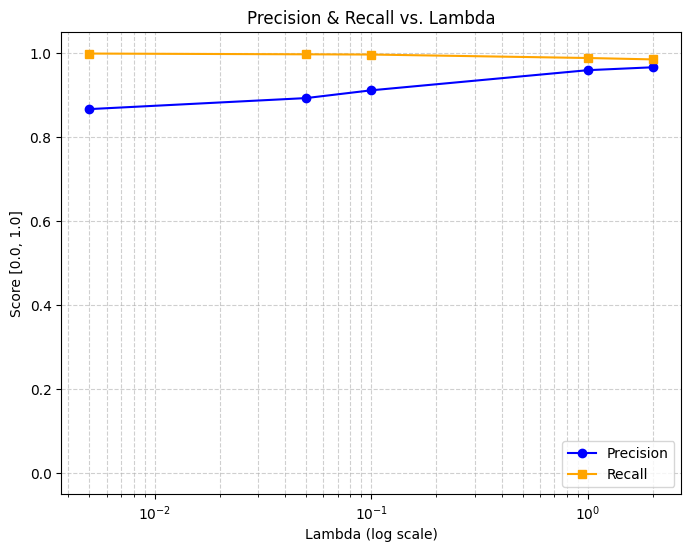

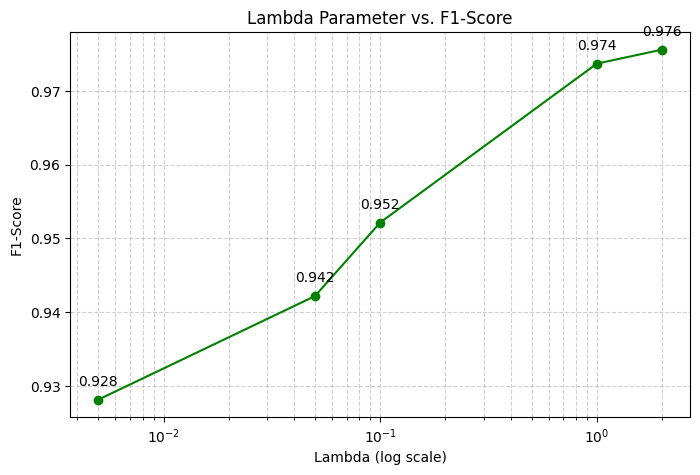

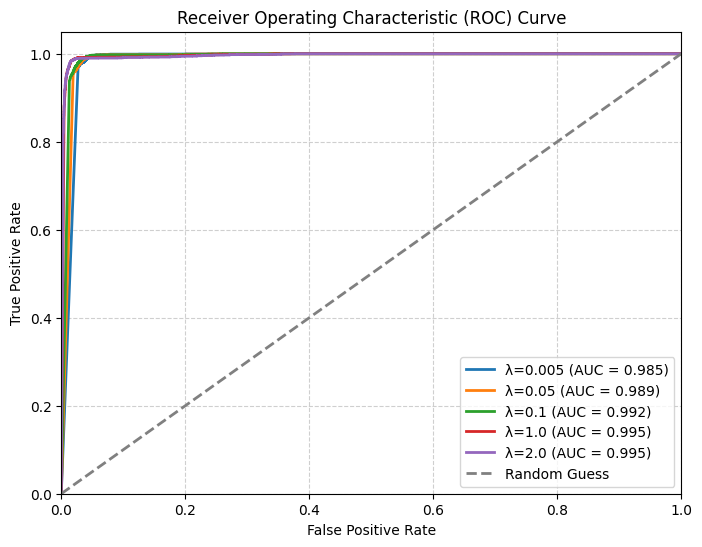

In [17]:
graphs = Plotter(stats)
graphs.plot_all()

### Additional Experimentation

We do not see any saturation by increasing lambda, so we try to increase it until we hit a wall or we see a trend where the precision and recall crosses each other. Additionally, we want to know the best model that can be drawn from the F1-score trend or the AUC of the ROC curves. We extend our experimentation on $\lambda = \{4.0,\ 8.0,\ 16.0,\ 32.0,\ 64.0\}$.

In [18]:
stats[4.0] = model.evaluate(test_set, lmbd=4.0)
stats[8.0] = model.evaluate(test_set, lmbd=8.0)
stats[16.0] = model.evaluate(test_set, lmbd=16.0)
stats[32.0] = model.evaluate(test_set, lmbd=32.0)
stats[64.0] = model.evaluate(test_set, lmbd=64.0)

        accuracy  precision    recall        f1
Lambda                                         
0.005   0.947211   0.866711  0.998967  0.928152
0.050   0.958227   0.892948  0.997160  0.942181
0.100   0.965806   0.911452  0.996643  0.952146
1.000   0.981757   0.959398  0.988381  0.973674
2.000   0.983167   0.966312  0.985025  0.975579
4.000   0.983255   0.970851  0.980377  0.975591
8.000   0.982286   0.972952  0.975213  0.974081
16.000  0.981052   0.975065  0.969274  0.972161
32.000  0.978056   0.978353  0.956881  0.967498
64.000  0.973121   0.982423  0.938033  0.959715
Table saved to: results/summary_table.csv


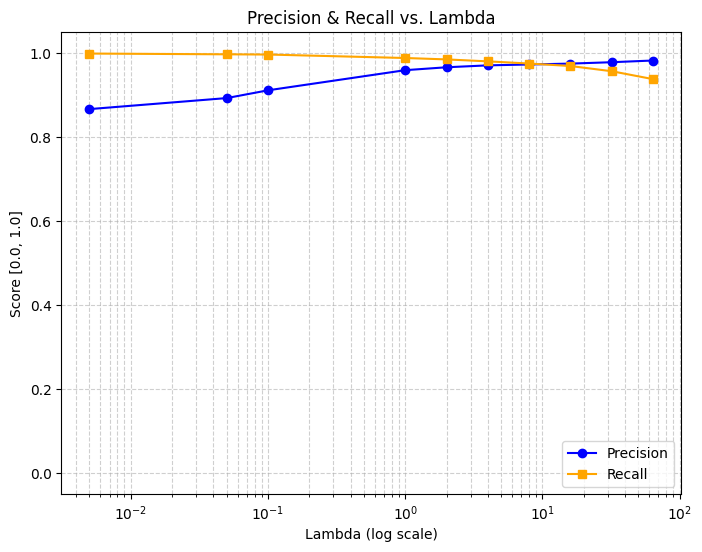

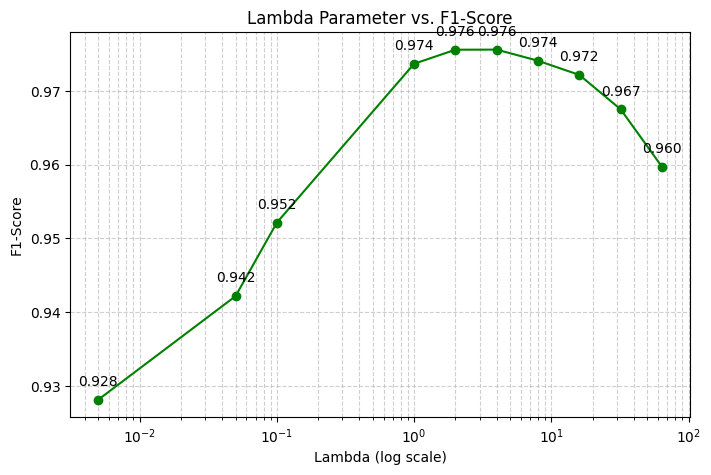

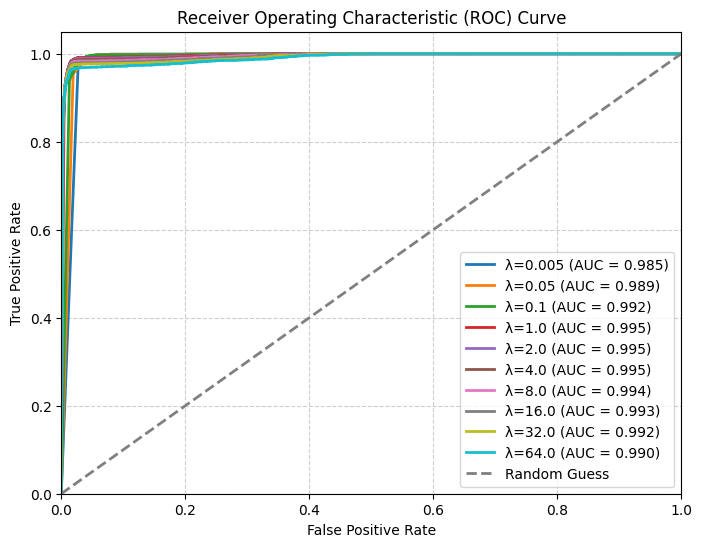

In [19]:
graphs = Plotter(stats)
graphs.plot_all()

### Best Model with Lambda Smoothing

We can probe at the best model that we see based on the F1-score and the ROC curve which is when $\lambda = \{2.0,\ 4.0\}$. We look at the confusion matrix when $\lambda=4.0$. The decision criteria is that the model must have a balanced "goodness" in both precision and recall.

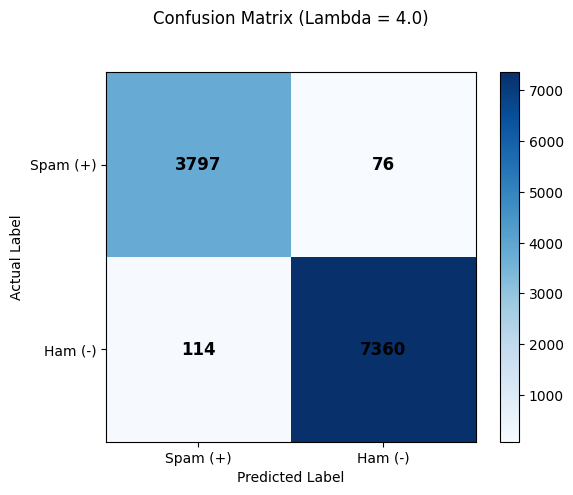

In [20]:
graphs.plot_confusion_matrix(4.0)

If we intend to maximize the recall, we can then just query the model with $\lambda =0.005$ which may not possess the highest AUC but will be least likely to put ham emails into the spam folder.

## Mutual Information

The program is notoriously heavy in both computation and memory which grows along the vocabulary size. We introduce mutual information defined as

$$
    I(x_i; \omega) = \sum_{x_i\in\{0, 1\}}\sum_{\omega\in\{h, s\}} P(x_i, \omega) \log\frac{P(x_i, \omega)}{P(x_i)P(\omega)}
$$

Again, we just inherit from the `SmoothNaiveBayesClassifier` to create the `MISmoothNaiveBayesClassifier` by incorporating the logic of the top $n$ features.

### Defining the Model

In [21]:
class MINaiveBayesClassifier(SmoothNaiveBayesClassifier):
    def apply_mutual_information(self, top_n=200):        
        total_docs = self.train_len
        p_ham = self.ham_prior
        p_spam = self.spam_prior
        
        mi_scores = []

        # We use this to avoid ZeroDivisionError
        sub_zero = 1e-12 

        for word, counts in self.vocab.items():
            # count[0] is Ham, count[1] is Spam
            word_ham = counts[0]
            word_spam = counts[1]
            not_word_ham = self.ham_count - word_ham
            not_word_spam = self.spam_count - word_spam

            # Joint Probabilities
            p_x1_ham = word_ham / total_docs
            p_x1_spam = word_spam / total_docs
            p_x0_ham = not_word_ham / total_docs
            p_x0_spam = not_word_spam / total_docs

            # Marginals
            p_x1 = (word_ham + word_spam) / total_docs
            p_x0 = (not_word_ham + not_word_spam) / total_docs

            # Mutual Information Formula
            mi = 0.0
            if p_x1_ham > 0: mi += p_x1_ham * np.log(p_x1_ham / (p_x1 * p_ham + sub_zero))
            if p_x1_spam > 0: mi += p_x1_spam * np.log(p_x1_spam / (p_x1 * p_spam + sub_zero))
            if p_x0_ham > 0: mi += p_x0_ham * np.log(p_x0_ham / (p_x0 * p_ham + sub_zero))
            if p_x0_spam > 0: mi += p_x0_spam * np.log(p_x0_spam / (p_x0 * p_spam + sub_zero))

            mi_scores.append((word, mi))

        # Sort by MI score descending
        mi_scores.sort(key=lambda x: x[1], reverse=True)
        top_features = [item[0] for item in mi_scores[:top_n]]

        # Shrink the active vocabulary strictly to the selected features
        self.vocab = {word: self.vocab[word] for word in top_features}
        self.vocab_len = len(self.vocab)
        
        return top_features

#### Model Training and Top-K Words

We can now run the model and extract the top 200 most informative words.

In [22]:
mi_model = MINaiveBayesClassifier()
mi_model.fit(train_set)
top_200_words = mi_model.apply_mutual_information(top_n=200)

print("\nTop 200 Most Informative Words")
for word in top_200_words:
    print(word, end=" ")


Top 200 Most Informative Words
I list the use if that on MIME there format University of would to Info it with be but Thanks have my anyone PM work and DMDX problem ASCII an AGAINST RIBBON file know MAIL can campaign as just so running HB other apache opt which am two same On some me CAMPAIGN our not do then are PUBLIC board seems This should does files If Outlook code By get Our question Express IC port time Microsoft need localhost z output input Department what any handyboard between problems a about system version However AM sender different Does one Handy RO host you error think CREN for V It Any Handyboard allowed motor In website probably test able point was either MimeOLE how Mozilla when tried mailing robot e ra find The than r display t At machine m item source thanks they like bit Discussion done web messages send or message Engineering Version seem also available Also Computer Science might working each them c page line handy simple put v connected itself such U data examp

#### Model Evaluation

We found out that the best $\lambda$ is $2.0$ or $4.0$ from our previous experiments. We use this hyperparameter to run the model with mutual information.

In [23]:
mi_stats = mi_model.evaluate(test_set, lmbd=4.0, visualize=False)

In [24]:
metrics_to_compare = ['precision', 'recall', 'f1']

best_recall_row = {metric: stats[0.005][metric] for metric in metrics_to_compare}
best_f1_row = {metric: stats[4.0][metric] for metric in metrics_to_compare}
mi_row = {metric: mi_stats[metric] for metric in metrics_to_compare}

comparison_df = pd.DataFrame([best_recall_row, best_f1_row, mi_row], 
                             index=['Best Recall (Lambda 0.005)',
                                    'Best F1 (Lambda 4.0)',
                                    'MI Top 200 (Lambda 4.0)'])

print(comparison_df)

comparison_df.to_csv('results/feature_selection_comparison.csv')

                            precision    recall        f1
Best Recall (Lambda 0.005)   0.866711  0.998967  0.928152
Best F1 (Lambda 4.0)         0.970851  0.980377  0.975591
MI Top 200 (Lambda 4.0)      0.593007  0.985283  0.740396


### Top n vs Precision and Recall

We evaluate the models with decreasing n for training efficiency. In this experiment, we determine the effect of the top most informative words in the performance of the model.

In [25]:
# Train once
mi_model = MINaiveBayesClassifier()
mi_model.fit(train_set)

# Decreasing n
n_values = [1000, 800, 600, 400, 200]
mi_stats = {}

for n in n_values:
    # Shrinks the vocab to top N
    mi_model.apply_mutual_information(top_n=n) 
    
    # Evaluate on that shrunken vocab and save to dictionary
    mi_stats[n] = mi_model.evaluate(test_set, lmbd=4.0, visualize=False)

comparison_mi_df = pd.DataFrame.from_dict(mi_stats, orient='index')
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
comparison_mi_df = comparison_mi_df[metrics_list]
comparison_mi_df.index.name = 'N (Top Words)'
print(comparison_mi_df)
comparison_mi_df.sort_index().to_csv('results/mi_vocab_size_comparison.csv')

               accuracy  precision    recall        f1
N (Top Words)                                         
1000           0.844452   0.689432  0.990447  0.812970
800            0.835199   0.676600  0.990705  0.804065
600            0.813255   0.648443  0.989156  0.783355
400            0.793161   0.624470  0.988381  0.765370
200            0.764167   0.593007  0.985283  0.740396


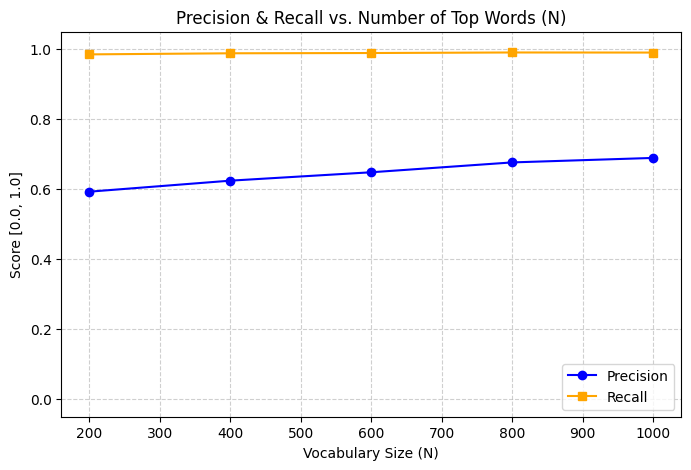

In [26]:
def plot_rp(plot_df):
    plt.figure(figsize=(8, 5))
    
    plt.plot(plot_df.index, plot_df['precision'], marker='o', linestyle='-', color='blue', label='Precision')
    plt.plot(plot_df.index, plot_df['recall'], marker='s', linestyle='-', color='orange', label='Recall')
    
    plt.title('Precision & Recall vs. Number of Top Words (N)')
    plt.xlabel('Vocabulary Size (N)')
    plt.ylabel('Score [0.0, 1.0]')
    plt.ylim([-0.05, 1.05])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')
    
    plt.savefig(os.path.join('results', 'mi_precision_recall_vs_n.png'), bbox_inches='tight', dpi=300)
    plt.show()
    
plot_rp(comparison_mi_df)

### Time and Space Complexities

We can argue that the main advantage of the mutual information model is that it requires significantly smaller memory and it runs almost instantly compared to the full vocabulary model. We investigate this.

**NOTE:** We preloaded the test data so that we focus on the model runtime ONLY, the time it takes to load the data may skew our results.

In [27]:
preloaded_test_data = []
for test in test_set:
    label, words = open_email(test)
    preloaded_test_data.append(words)

#### Time Complexity

In [28]:
# For baseline model
start_time = time.perf_counter()
for words in preloaded_test_data:
    model.predict(words, lmbd=4.0)
fv_time = time.perf_counter() - start_time
print(f"Full Vocab Runtime: {fv_time:.5f} seconds")

# For Mi model
time_mi_model = MINaiveBayesClassifier()
time_mi_model.fit(train_set)

n_values = [1000, 800, 600, 400, 200]
time_stats = {}

for n in n_values:
    time_mi_model.apply_mutual_information(top_n=n)
    
    start_time = time.perf_counter()
    for words in preloaded_test_data:
        time_mi_model.predict(words, lmbd=4.0)
    mi_time = time.perf_counter() - start_time
    
    time_faster_percent = ((fv_time - mi_time) / fv_time) * 100
    
    time_stats[n] = {
        'Runtime (s)': mi_time,
        'Time Faster (%)': time_faster_percent
    }
    
# Print and save results
time_df = pd.DataFrame.from_dict(time_stats, orient='index')
time_df.index.name = 'N (Top Words)'
display(time_df)
time_df.to_csv(os.path.join('results', 'time_complexity.csv'))

Full Vocab Runtime: 1.93996 seconds


,Runtime (s),Time Faster (%)
N (Top Words),,
1000,0.816861,57.892969
800,0.770428,60.286473
600,0.720827,62.843286
400,0.654178,66.278821
200,0.510246,73.698168


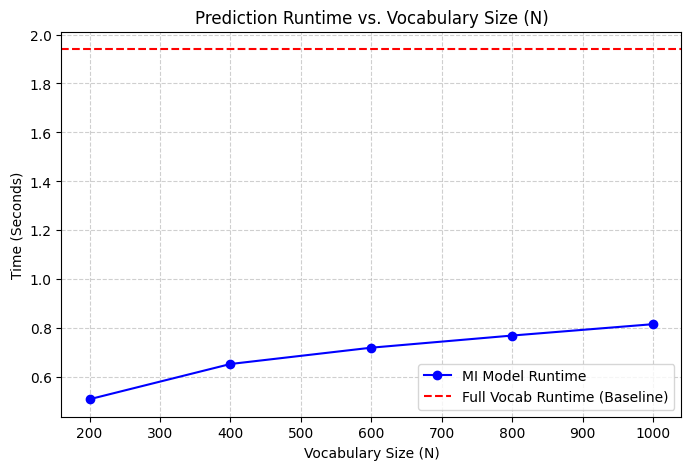

In [29]:
# Plot time complexity comparison
plot_time_df = time_df.sort_index()
plt.figure(figsize=(8, 5))
plt.plot(plot_time_df.index, plot_time_df['Runtime (s)'], marker='o', linestyle='-', color='blue', label='MI Model Runtime')
plt.axhline(y=fv_time, color='red', linestyle='--', label='Full Vocab Runtime (Baseline)')

plt.title('Prediction Runtime vs. Vocabulary Size (N)')
plt.xlabel('Vocabulary Size (N)')
plt.ylabel('Time (Seconds)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join('results', 'time_complexity_plot.png'), bbox_inches='tight', dpi=300)
plt.show()

#### Space Complexity

In [30]:
# For baseline model
fv_kb = len(pickle.dumps(model)) / 1024
print(f"Full Vocab Memory: {fv_kb:.2f} KB")

# For Mi model
space_mi_model = MINaiveBayesClassifier()
space_mi_model.fit(train_set)

n_values = [1000, 800, 600, 400, 200]
space_stats = {}

for n in n_values:
    space_mi_model.apply_mutual_information(top_n=n)
    
    mi_kb = len(pickle.dumps(space_mi_model)) / 1024
    memory_saved_percent = ((fv_kb - mi_kb) / fv_kb) * 100
    
    space_stats[n] = {
        'Memory (KB)': mi_kb,
        'Memory Saved (%)': memory_saved_percent
    }

space_df = pd.DataFrame.from_dict(space_stats, orient='index')
space_df.index.name = 'N (Top Words)'
display(space_df)
space_df.to_csv(os.path.join('results', 'space_complexity.csv'))

Full Vocab Memory: 2485.20 KB


,Memory (KB),Memory Saved (%)
N (Top Words),,
1000,17.407227,99.299564
800,13.926758,99.439612
600,10.492188,99.577813
400,7.017578,99.717625
200,3.515625,99.858538


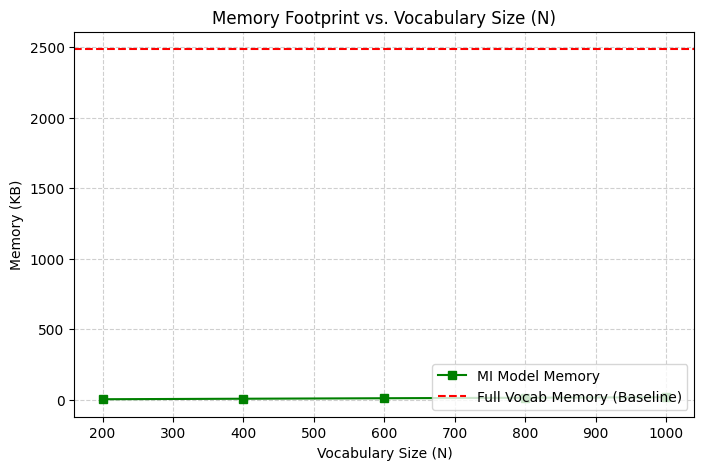

In [31]:
plot_space_df = space_df.sort_index()
plt.figure(figsize=(8, 5))
plt.plot(plot_space_df.index, plot_space_df['Memory (KB)'], marker='s', linestyle='-', color='green', label='MI Model Memory')
plt.axhline(y=fv_kb, color='red', linestyle='--', label='Full Vocab Memory (Baseline)')

plt.title('Memory Footprint vs. Vocabulary Size (N)')
plt.xlabel('Vocabulary Size (N)')
plt.ylabel('Memory (KB)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join('results', 'space_complexity_plot.png'), bbox_inches='tight', dpi=300)
plt.show()